In [1]:
import os
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
import joblib

from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path.cwd().parent))
from src.utils import get_project_root, download_preprocessed_dataset

MODEL_NAME = "cointegrated/rubert-tiny2"
BATCH_SIZE = 32
MAX_LENGTH = 512
RANDOM_SEED = 42

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
PROJECT_ROOT = get_project_root()
PREPROCESSED_DATASET_PATH = PROJECT_ROOT / "data" / "preprocessed" / "clean_data.parquet"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts" / "nn-baseline"
EMBEDDINGS_PATH = PROJECT_ROOT / "data" / "preprocessed" / "embeddings"

os.makedirs(ARTIFACTS_PATH, exist_ok=True)
os.makedirs(EMBEDDINGS_PATH, exist_ok=True)

In [4]:
try:
    df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
except FileNotFoundError:
    try:
        download_preprocessed_dataset()
        df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
    except Exception as ex:
        print(f"Ошибка: {ex}")

In [5]:
df.head()

,news,labels,category_name,text_len,words_count,news_tfidf_ready
0,"Российские пожарные спасли детеныша косули, по...",0,Климат,1240,185,российский пожарный спасти детёныш косуля попа...
1,Житель Сахалина заметил на острове орлана — кр...,0,Климат,858,129,житель сахалин заметить остров орлан крупный х...
2,Российские заводы начнут работать по-новому ра...,0,Климат,1117,140,российский завод начать работать спасение план...
3,Неравнодушные россияне спасли слепого и глухог...,0,Климат,999,156,неравнодушный россиянин спасти слепой глухой е...
4,Специалисты предупредили граждан Британии о во...,0,Климат,1914,256,специалист предупредить гражданин британия воз...


In [6]:
X = df["news"]
y = df["labels"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

In [7]:
class_names = df.groupby("labels")["category_name"].first().values
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 56700, Test: 14175


In [8]:
def evaluate_model(
    model,
    model_name
) -> None:

    """
    Строит confusion matrix и csv отчет по classification report для заданной модели на test
    """
    
    y_pred = model.predict(test_embeddings)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_PATH / f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()
    
    print("\n" + "="*60)
    print(f"Classification Report - {model_name}")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=class_names))

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    class_rows = [cn for cn in class_names if cn in report_df.index]
    class_df = report_df.loc[class_rows].copy()
    class_df["support"] = class_df["support"].astype(int)

    out_df = class_df.reset_index().rename(columns={"index": "class"})
    out_path = ARTIFACTS_PATH / f"{model_name}_class_report.csv"
    out_df.to_csv(out_path, index=False)

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(83828, 312, padding_idx=0)
    (position_embeddings): Embedding(2048, 312)
    (token_type_embeddings): Embedding(2, 312)
    (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-2): 3 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=312, out_features=312, bias=True)
            (key): Linear(in_features=312, out_features=312, bias=True)
            (value): Linear(in_features=312, out_features=312, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=312, out_features=312, bias=True)
            (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
   

In [10]:
def get_embeddings(texts, tokenizer, model, device, batch_size, max_length):
    """Извлекает [CLS] эмбеддинги для списка текстов"""
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[i:i+batch_size].tolist()
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        embeddings.append(cls_embeddings)
    
    return np.vstack(embeddings)

In [11]:
TRAINT_EMBEDDINGS_PATH = EMBEDDINGS_PATH / "train_rubert_embeddings.npy"
TEST_EMBEDDINGS_PATH = EMBEDDINGS_PATH / "test_rubert_embeddings.npy"

train_embeddings = get_embeddings(X_train, tokenizer, model, DEVICE, BATCH_SIZE, MAX_LENGTH)
test_embeddings = get_embeddings(X_test, tokenizer, model, DEVICE, BATCH_SIZE, MAX_LENGTH)
    
np.save(TRAINT_EMBEDDINGS_PATH, train_embeddings)
np.save(TEST_EMBEDDINGS_PATH, test_embeddings)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Extracting embeddings:   0%|          | 0/1772 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/443 [00:00<?, ?it/s]

Train embeddings shape: (56700, 312)
Test embeddings shape: (14175, 312)


In [12]:
tokens = tokenizer(X_train.iloc[0], max_length=MAX_LENGTH, truncation=True)
print(f"Original: {len(X_train.iloc[0])} chars")
print(f"Tokens: {len(tokens['input_ids'])}")

Original: 1334 chars
Tokens: 273


In [13]:
lr_basic = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_basic.fit(train_embeddings, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred = lr_basic.predict(test_embeddings)
print(f"Basic LogReg F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

Basic LogReg F1-macro: 0.8380


In [15]:
param_grid = {
    "C": [0.1, 0.3, 1, 3, 5, 10],
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1
)

In [16]:
grid.fit(train_embeddings, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.1, 0.3, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [17]:
print(f"\nBest params: {grid.best_params_}")
print(f"Best CV F1-macro: {grid.best_score_:.4f}")


Best params: {'C': 1}
Best CV F1-macro: 0.8378


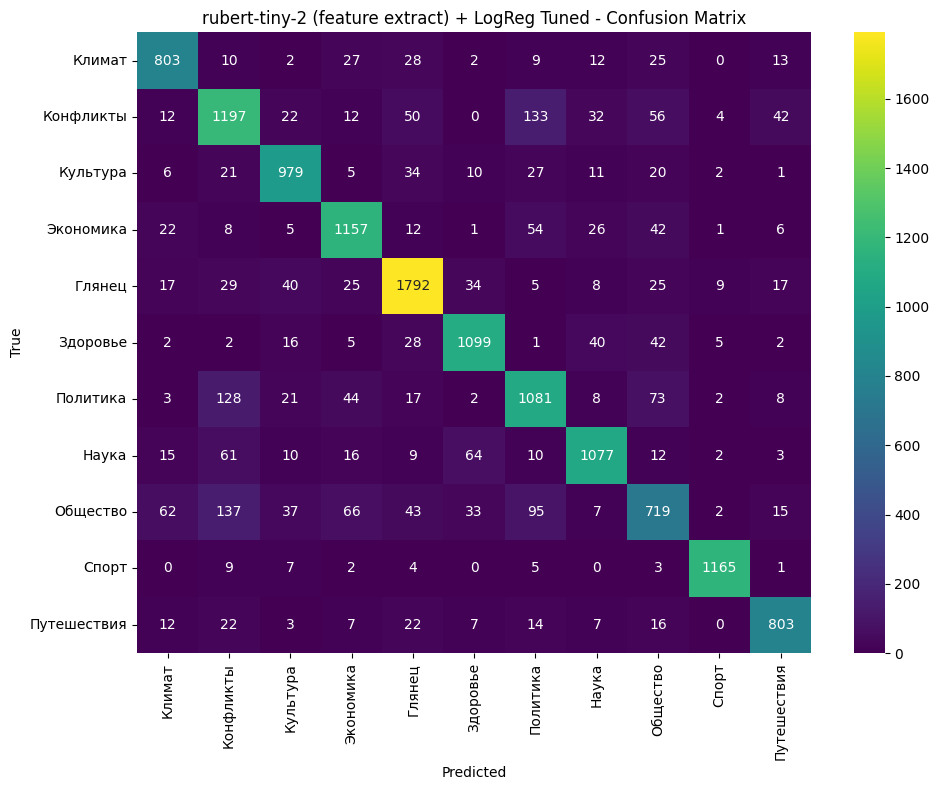


Classification Report - rubert-tiny-2 (feature extract) + LogReg Tuned
              precision    recall  f1-score   support

      Климат       0.84      0.86      0.85       931
   Конфликты       0.74      0.77      0.75      1560
    Культура       0.86      0.88      0.87      1116
   Экономика       0.85      0.87      0.86      1334
      Глянец       0.88      0.90      0.89      2001
    Здоровье       0.88      0.88      0.88      1242
    Политика       0.75      0.78      0.77      1387
       Наука       0.88      0.84      0.86      1279
    Общество       0.70      0.59      0.64      1216
       Спорт       0.98      0.97      0.98      1196
 Путешествия       0.88      0.88      0.88       913

    accuracy                           0.84     14175
   macro avg       0.84      0.84      0.84     14175
weighted avg       0.84      0.84      0.84     14175



In [18]:
evaluate_model(grid, "rubert-tiny-2 (feature extract) + LogReg Tuned")